# RQ2: Sensitivity-Aware DP-SGD for Emotion Detection
**Research Question**: To what extent does sensitivity-aware noise injection in DP-SGD (based on emotion intensity and utterance length) improve the privacy–utility trade-off compared to uniform noise mechanisms?

## Methodology:
1. Compute per-sample **sensitivity** from emotion intensity + utterance length
2. Train 2 RoBERTa-base DP-SGD variants (both ε=8, δ=1e-5):
   - **UNIFORM_DP**: Standard DP-SGD with uniform noise (baseline)
   - **SENSITIVITY_DP**: DP-SGD with sensitivity-weighted loss
3. Evaluate utility (F1-macro) and privacy (MIA AUC) **overall** and **per sensitivity tier**
4. Compare privacy–utility trade-offs

## Key Insight:
Sensitivity-weighted loss scales each sample's gradient contribution by inverse sensitivity.
Under uniform DP noise, high-sensitivity samples (dampened gradients) get **more effective privacy**,
while low-sensitivity samples (amplified gradients) retain **more utility**.
The formal DP guarantee (ε) is unchanged — only the signal-to-noise ratio varies per sample.

In [1]:
!pip install opacus

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.4/254.4 kB 7.0 MB/s eta 0:00:00


In [2]:
import os
import sys
import pathlib
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import warnings
from opacus import PrivacyEngine
from opacus.utils.batch_memory_manager import BatchMemoryManager

warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [3]:
import os
import pathlib
import sys

# 1. Mount Google Drive (if Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    IN_COLAB = False
    print("Not running in Colab environment")

# 2. Find Project Root and Data Paths
if IN_COLAB:
    POSSIBLE_ROOTS = ['/content/drive/MyDrive', '/content/drive/My Drive']
    PROJECT_ROOT = None
    for pr in POSSIBLE_ROOTS:
        if os.path.exists(pr):
            PROJECT_ROOT = pathlib.Path(pr)
            break
    if PROJECT_ROOT is None:
        PROJECT_ROOT = pathlib.Path('/content/drive/MyDrive')
else:
    PROJECT_ROOT = pathlib.Path(os.getcwd())
    if 'src' in PROJECT_ROOT.parts:
        PROJECT_ROOT = PROJECT_ROOT.parents[PROJECT_ROOT.parts.index('src') - 1]

print(f"Project Root: {PROJECT_ROOT}")
sys.path.append(str(PROJECT_ROOT))

RAW_PATH = PROJECT_ROOT / 'content' / 'data' / 'raw' / 'go_emotions_dataset.csv'
CLEANED_PATH = PROJECT_ROOT / 'content' / 'data' / 'processed' / 'go_emotions_cleaned.csv'
OUTPUT_DIR = PROJECT_ROOT / 'models' / 'rq2_sensitivity'
REPORT_DIR = PROJECT_ROOT / 'reports' / 'rq2'

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# Load datasets
df_raw = pd.read_csv(RAW_PATH)
df_cleaned = pd.read_csv(CLEANED_PATH)

print(f"Raw: {df_raw.shape} | Cleaned: {df_cleaned.shape}")

# Identify emotion columns
emotion_columns = ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring',
                   'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval',
                   'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief',
                   'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization',
                   'relief', 'remorse', 'sadness', 'surprise', 'neutral']
num_emotions = len(emotion_columns)

Mounted at /content/drive
Project Root: /content/drive/MyDrive
Raw: (211225, 31) | Cleaned: (57414, 32)


## Prepare Train/Val/Test Splits
Same splits as RQ1 for comparability.

In [4]:
meta_cols = {'id', 'text', 'example_very_unclear', 'clean_text', 'num_emotions', 'emotion_bin'}
emotion_cols = [col for col in df_raw.columns if col not in meta_cols]
print(f"emotion_cols: {len(emotion_cols)} → {emotion_cols}")

emotion_cols: 28 → ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


In [5]:
# Merge datasets on ID
df = df_raw.copy()
df = df.merge(df_cleaned[['id', 'clean_text']], on='id', how='inner')

df['num_emotions'] = df[emotion_cols].sum(axis=1)
df['emotion_bin'] = pd.qcut(df['num_emotions'], q=3, duplicates='drop')

n_bins = len(df['emotion_bin'].cat.categories)
label_map = {i: label for i, label in enumerate(['low', 'med', 'high'][:n_bins])}
df['emotion_bin'] = df['emotion_bin'].cat.rename_categories(label_map)

# 60% train, 20% val, 20% test — SAME random_state as RQ1
train_idx, temp_idx = train_test_split(
    range(len(df)), test_size=0.4, random_state=42, stratify=df['emotion_bin']
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, random_state=42, stratify=df.loc[temp_idx, 'emotion_bin']
)

df_train = df.iloc[train_idx].reset_index(drop=True)
df_val = df.iloc[val_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)

train_labels = df_train[emotion_cols].values.astype(np.float32)
val_labels = df_val[emotion_cols].values.astype(np.float32)
test_labels = df_test[emotion_cols].values.astype(np.float32)

print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")
print(f"Label shape: {train_labels.shape}")

Train: 125514 | Val: 41838 | Test: 41838
Label shape: (125514, 28)


## Sensitivity Computation
Per-sample sensitivity $S_i$ based on:
- **Emotion intensity**: number of active emotion labels (higher = more sensitive)
- **Utterance length**: character count of text (longer = more identifying)

$$S_i = \alpha \cdot \text{intensity\_norm}_i + \beta \cdot \text{length\_norm}_i$$

where $\alpha = 0.6$, $\beta = 0.4$ (emotion content is more privacy-relevant than length for mental health data).

In [6]:
def compute_sensitivity(texts, emotion_labels, alpha=0.6, beta=0.4):
    """
    Compute per-sample sensitivity score in [0, 1].

    Args:
        texts: list of strings
        emotion_labels: np.array of shape (N, num_emotions) with binary labels
        alpha: weight for emotion intensity (default 0.6)
        beta: weight for utterance length (default 0.4)
    Returns:
        np.array of sensitivity scores in [0, 1]
    """
    # Emotion intensity: count of active labels, normalized by realistic max (5)
    intensity = emotion_labels.sum(axis=1)
    intensity_norm = np.clip(intensity / 5.0, 0.0, 1.0)

    # Utterance length: character count, normalized by 512 (RoBERTa practical max)
    lengths = np.array([len(str(t)) for t in texts])
    length_norm = np.clip(lengths / 512.0, 0.0, 1.0)

    sensitivity = alpha * intensity_norm + beta * length_norm
    return sensitivity.astype(np.float32)


def assign_sensitivity_tier(sensitivity):
    """Assign low/medium/high tier based on sensitivity score."""
    tiers = np.where(sensitivity < 0.3, 'low',
            np.where(sensitivity < 0.6, 'medium', 'high'))
    return tiers


# Prepare texts (raw text, same as RQ1's V0/V2)
train_texts = df_train['text'].astype(str).str.lower().tolist()
val_texts   = df_val['text'].astype(str).str.lower().tolist()
test_texts  = df_test['text'].astype(str).str.lower().tolist()

# Compute sensitivity for all splits
train_sensitivity = compute_sensitivity(train_texts, train_labels)
val_sensitivity   = compute_sensitivity(val_texts, val_labels)
test_sensitivity  = compute_sensitivity(test_texts, test_labels)

# Assign tiers
train_tiers = assign_sensitivity_tier(train_sensitivity)
test_tiers  = assign_sensitivity_tier(test_sensitivity)

print("=== Training Set Sensitivity ===")
print(f"  Mean: {train_sensitivity.mean():.3f} | Std: {train_sensitivity.std():.3f}")
print(f"  Min:  {train_sensitivity.min():.3f} | Max: {train_sensitivity.max():.3f}")
print(f"\n  Tier distribution:")
for tier in ['low', 'medium', 'high']:
    count = (train_tiers == tier).sum()
    print(f"    {tier:>6}: {count:,} ({count/len(train_tiers):.1%})")

=== Training Set Sensitivity ===
  Mean: 0.196 | Std: 0.069
  Min:  0.002 | Max: 0.729

  Tier distribution:
       low: 113,149 (90.1%)
    medium: 12,238 (9.8%)
      high: 127 (0.1%)


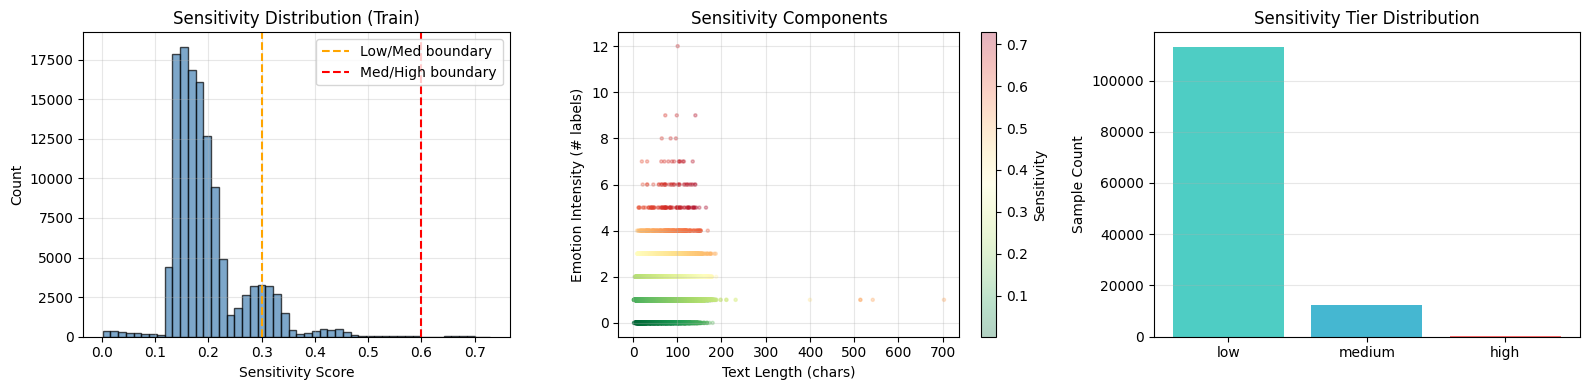

Sensitivity distribution saved.


In [7]:
# Visualize sensitivity distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribution
axes[0].hist(train_sensitivity, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(0.3, color='orange', linestyle='--', label='Low/Med boundary')
axes[0].axvline(0.6, color='red', linestyle='--', label='Med/High boundary')
axes[0].set_xlabel('Sensitivity Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Sensitivity Distribution (Train)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Intensity vs Length contribution
intensity = train_labels.sum(axis=1)
lengths = np.array([len(t) for t in train_texts])
scatter = axes[1].scatter(lengths, intensity, c=train_sensitivity,
                          cmap='RdYlGn_r', alpha=0.3, s=5)
plt.colorbar(scatter, ax=axes[1], label='Sensitivity')
axes[1].set_xlabel('Text Length (chars)')
axes[1].set_ylabel('Emotion Intensity (# labels)')
axes[1].set_title('Sensitivity Components')
axes[1].grid(alpha=0.3)

# Tier counts
tier_counts = pd.Series(train_tiers).value_counts().reindex(['low', 'medium', 'high'])
axes[2].bar(tier_counts.index, tier_counts.values,
            color=['#4ecdc4', '#45b7d1', '#ff6b6b'])
axes[2].set_ylabel('Sample Count')
axes[2].set_title('Sensitivity Tier Distribution')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, 'rq2_sensitivity_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Sensitivity distribution saved.")

## Dataset and Model Definitions

In [8]:
class SensitivityEmotionDataset(Dataset):
    """Emotion dataset that carries per-sample sensitivity scores."""
    def __init__(self, texts, labels, sensitivities, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.sensitivities = sensitivities
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(self.labels[idx]).float(),
            'sensitivity': torch.tensor(self.sensitivities[idx]).float()
        }

In [9]:
class RobertaHeadOnlyClassifier(torch.nn.Module):
    """
    Freeze ALL RoBERTa weights. Train a 2-layer MLP head on mean-pooled embeddings.
    Same architecture as RQ1's DP variants for fair comparison.
    """
    def __init__(self, roberta_model, num_labels, hidden_dim=256, dropout=0.1):
        super().__init__()
        self.roberta = roberta_model.roberta
        hidden_size  = roberta_model.config.hidden_size

        for param in self.roberta.parameters():
            param.requires_grad = False

        self.classifier = torch.nn.Sequential(
            torch.nn.Linear(hidden_size, hidden_dim),
            torch.nn.GELU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(hidden_dim, num_labels),
        )

        for m in self.classifier:
            if isinstance(m, torch.nn.Linear):
                torch.nn.init.xavier_uniform_(m.weight)
                torch.nn.init.zeros_(m.bias)

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        hidden = outputs.last_hidden_state
        mask   = attention_mask.unsqueeze(-1).float()
        pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1)
        return self.classifier(pooled)

## Training Functions

In [10]:
def find_best_threshold(model, val_loader, val_labels_val, device, is_dp=False):
    """Sweep thresholds on validation set and return the one maximising F1-macro."""
    model.eval()
    val_preds_raw = []

    with torch.no_grad():
        for batch in val_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs        = model(input_ids=input_ids, attention_mask=attention_mask)
            logits         = outputs if isinstance(outputs, torch.Tensor) else outputs.logits
            probs          = torch.sigmoid(logits).cpu().numpy()
            val_preds_raw.append(probs)

    val_preds_raw = np.vstack(val_preds_raw)

    mean_prob     = val_preds_raw.mean()
    frac_above_05 = (val_preds_raw > 0.05).mean()
    frac_above_30 = (val_preds_raw > 0.30).mean()
    logit_proxy   = np.log(val_preds_raw.mean() / (1 - val_preds_raw.mean() + 1e-9))
    print(f"   [diag] mean_prob={mean_prob:.4f} | "
          f">0.05: {frac_above_05:.2%} | "
          f">0.30: {frac_above_30:.2%} | "
          f"mean_logit≈{logit_proxy:.3f}")

    best_t, best_f1 = 0.3, 0.0
    for t in np.arange(0.05, 0.95, 0.05):
        preds = (val_preds_raw > t).astype(int)
        f1    = f1_score(val_labels_val, preds, average='macro', zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t

    return best_t, best_f1


def train_rq2_model(variant_name, train_texts, val_texts,
                    train_labels_val, val_labels_val,
                    train_sensitivity_scores, val_sensitivity_scores,
                    sensitivity_weighted=False,
                    epsilon=8.0, delta=1e-5,
                    max_grad_norm=1.0, epochs=10, threshold=0.3):
    """
    Train a DP-SGD model with optional sensitivity-weighted loss.

    When sensitivity_weighted=True:
      - Each sample's loss is scaled by weight_i = 1 / (S_i + 0.1)
      - Weights are normalized so mean = 1 (preserves gradient magnitude)
      - High-sensitivity samples get smaller gradients → noise dominates → more private
      - Low-sensitivity samples get larger gradients → better learning → more utility
    """
    print(f"\n{'='*60}")
    print(f"Training: {variant_name}")
    print(f"DP: ε={epsilon}, δ={delta} | Sensitivity-weighted: {sensitivity_weighted}")
    print(f"{'='*60}")

    import gc
    gc.collect()
    torch.cuda.empty_cache()

    model_name = 'roberta-base'
    tokenizer  = AutoTokenizer.from_pretrained(model_name)
    num_labels = train_labels_val.shape[1]

    physical_batch_size = 32
    logical_batch_size  = 256
    lr                  = 1e-3

    # Build model
    base_model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=num_labels, problem_type='multi_label_classification'
    )
    model = RobertaHeadOnlyClassifier(
        roberta_model=base_model, num_labels=num_labels, hidden_dim=256, dropout=0.1
    )
    del base_model

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f" Trainable     : {trainable:,} / {total:,} params")
    model.to(device)

    # pos_weight: sqrt dampening with tight cap (same as RQ1 DP config)
    label_pos  = train_labels_val.sum(axis=0)
    label_neg  = len(train_labels_val) - label_pos
    raw_weight = label_neg / (label_pos + 1e-6)
    pos_weight = torch.tensor(
        np.sqrt(raw_weight), dtype=torch.float32
    ).clamp(min=1.0, max=3.0).to(device)
    print(f" pos_weight    : min={pos_weight.min():.1f}, max={pos_weight.max():.1f}, mean={pos_weight.mean():.1f}")

    # DataLoaders
    train_dataset = SensitivityEmotionDataset(
        train_texts, train_labels_val, train_sensitivity_scores, tokenizer
    )
    val_dataset = SensitivityEmotionDataset(
        val_texts, val_labels_val, val_sensitivity_scores, tokenizer
    )
    train_loader = DataLoader(
        train_dataset, batch_size=logical_batch_size, shuffle=True, drop_last=True
    )
    val_loader = DataLoader(val_dataset, batch_size=32)

    optimizer = Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    # DP-SGD via Opacus
    privacy_engine = PrivacyEngine()
    model.train()
    model, optimizer, train_loader = privacy_engine.make_private_with_epsilon(
        module=model,
        optimizer=optimizer,
        data_loader=train_loader,
        target_epsilon=epsilon,
        target_delta=delta,
        epochs=epochs,
        max_grad_norm=max_grad_norm,
        poisson_sampling=False,
    )
    noise_mult = optimizer.noise_multiplier
    print(f" Noise σ       : {noise_mult:.4f} | effective std={noise_mult * max_grad_norm:.4f}")
    print(f" Batch         : logical={logical_batch_size}, physical={physical_batch_size}")

    # No LR scheduler for DP (constant LR works best under noise)

    # Training loop
    best_f1        = 0.0
    best_threshold = threshold
    epoch_results  = []

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        model.train()
        train_loss  = 0.0
        num_batches = 0

        with BatchMemoryManager(
            data_loader=train_loader,
            max_physical_batch_size=physical_batch_size,
            optimizer=optimizer,
        ) as memory_safe_loader:
            for batch in tqdm(memory_safe_loader, desc=f'Training ({variant_name})'):
                optimizer.zero_grad()
                input_ids      = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels         = batch['labels'].to(device)
                sensitivity    = batch['sensitivity'].to(device)  # (B,)

                logits = model(input_ids=input_ids, attention_mask=attention_mask)

                # Per-sample loss: (B, num_labels) → (B,)
                per_sample_loss = torch.nn.functional.binary_cross_entropy_with_logits(
                    logits, labels, pos_weight=pos_weight, reduction='none'
                ).mean(dim=1)

                if sensitivity_weighted:
                    # Weight by inverse sensitivity: low-sensitivity → high weight (more utility)
                    # high-sensitivity → low weight (noise dominates → more privacy)
                    inv_sens = 1.0 / (sensitivity + 0.1)
                    weights  = inv_sens / inv_sens.mean()  # normalize to mean=1
                    loss = (per_sample_loss * weights).mean()
                else:
                    loss = per_sample_loss.mean()

                loss.backward()
                optimizer.step()
                train_loss  += loss.item()
                num_batches += 1

        avg_loss  = train_loss / max(num_batches, 1)
        eps_spent = privacy_engine.get_epsilon(delta=delta)
        print(f" Train Loss: {avg_loss:.4f} | ε spent: {eps_spent:.2f}")

        opt_threshold, f1_macro = find_best_threshold(
            model, val_loader, val_labels_val, device, is_dp=True
        )
        print(f" Val F1-macro: {f1_macro:.4f} (threshold={opt_threshold:.2f})")

        if f1_macro > best_f1:
            best_f1        = f1_macro
            best_threshold = opt_threshold
            torch.save(
                model.state_dict(),
                os.path.join(OUTPUT_DIR, f'{variant_name}_best.pt')
            )

        epoch_results.append({
            'epoch': epoch + 1, 'loss': avg_loss,
            'f1': f1_macro, 'epsilon': eps_spent
        })

    print(f"\n Best F1: {best_f1:.4f} (threshold={best_threshold:.2f})")
    model.cpu()
    torch.cuda.empty_cache()

    return {
        'model': model, 'tokenizer': tokenizer,
        'best_f1': best_f1, 'results': pd.DataFrame(epoch_results),
        'variant': variant_name, 'threshold': best_threshold, 'is_dp': True
    }

## Train 2 DP-SGD Variants
Both use identical ε=8, δ=1e-5, architecture, and data.
The **only difference** is whether the loss is weighted by inverse sensitivity.

In [11]:
# Variant A: Uniform DP-SGD (standard — same as RQ1's V2)
result_uniform = train_rq2_model(
    'UNIFORM_DP',
    train_texts, val_texts,
    train_labels, val_labels,
    train_sensitivity, val_sensitivity,
    sensitivity_weighted=False,
    epsilon=8.0, delta=1e-5,
    max_grad_norm=1.0, epochs=10, threshold=0.3
)


Training: UNIFORM_DP
DP: ε=8.0, δ=1e-05 | Sensitivity-weighted: False


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

 Train Loss: 0.2963 | ε spent: 7.44
   [diag] mean_prob=0.0844 | >0.05: 45.33% | >0.30: 5.18% | mean_logit≈-2.384
 Val F1-macro: 0.1854 (threshold=0.15)

Epoch 9/10


Training (UNIFORM_DP): 100%|██████████| 3920/3920 [03:52<00:00, 16.87it/s]


 Train Loss: 0.2940 | ε spent: 7.72
   [diag] mean_prob=0.0818 | >0.05: 41.30% | >0.30: 5.40% | mean_logit≈-2.418
 Val F1-macro: 0.1888 (threshold=0.15)

Epoch 10/10


Training (UNIFORM_DP): 100%|██████████| 3920/3920 [03:50<00:00, 16.98it/s]


 Train Loss: 0.2920 | ε spent: 8.00
   [diag] mean_prob=0.0820 | >0.05: 40.83% | >0.30: 5.54% | mean_logit≈-2.416
 Val F1-macro: 0.1943 (threshold=0.20)

 Best F1: 0.1943 (threshold=0.20)


In [12]:
# Variant B: Sensitivity-Weighted DP-SGD
result_sensitivity = train_rq2_model(
    'SENSITIVITY_DP',
    train_texts, val_texts,
    train_labels, val_labels,
    train_sensitivity, val_sensitivity,
    sensitivity_weighted=True,
    epsilon=8.0, delta=1e-5,
    max_grad_norm=1.0, epochs=10, threshold=0.3
)


Training: SENSITIVITY_DP
DP: ε=8.0, δ=1e-05 | Sensitivity-weighted: True


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 Trainable     : 204,060 / 124,259,100 params
 pos_weight    : min=1.7, max=3.0, mean=3.0
 Noise σ       : 0.4826 | effective std=0.4826
 Batch         : logical=256, physical=32

Epoch 1/10


Training (SENSITIVITY_DP): 100%|██████████| 3920/3920 [03:51<00:00, 16.96it/s]


...

 Train Loss: 0.2744 | ε spent: 7.44
   [diag] mean_prob=0.0832 | >0.05: 44.12% | >0.30: 5.22% | mean_logit≈-2.400
 Val F1-macro: 0.1843 (threshold=0.15)

Epoch 9/10


Training (SENSITIVITY_DP): 100%|██████████| 3920/3920 [03:50<00:00, 17.00it/s]


 Train Loss: 0.2722 | ε spent: 7.72
   [diag] mean_prob=0.0810 | >0.05: 40.46% | >0.30: 5.37% | mean_logit≈-2.429
 Val F1-macro: 0.1909 (threshold=0.15)

Epoch 10/10


Training (SENSITIVITY_DP): 100%|██████████| 3920/3920 [03:50<00:00, 17.00it/s]


 Train Loss: 0.2710 | ε spent: 8.00
   [diag] mean_prob=0.0795 | >0.05: 40.44% | >0.30: 5.26% | mean_logit≈-2.450
 Val F1-macro: 0.1927 (threshold=0.15)

 Best F1: 0.1927 (threshold=0.15)


In [13]:
results_all = [result_uniform, result_sensitivity]
print("Both variants trained successfully!")

Both variants trained successfully!


## Test Set Evaluation: Overall + Per-Tier

In [14]:
def evaluate_variant(result_dict, test_texts, test_labels_eval):
    """Evaluate on test set using trained threshold."""
    model     = result_dict['model']
    tokenizer = result_dict['tokenizer']
    variant   = result_dict['variant']
    threshold = result_dict.get('threshold', 0.3)

    model.to(device)
    model.eval()

    test_dataset = SensitivityEmotionDataset(
        test_texts, test_labels_eval, test_sensitivity, tokenizer
    )
    test_loader = DataLoader(test_dataset, batch_size=32)

    test_preds = []
    test_logits_all = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc=f'Testing {variant}'):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits  = outputs if isinstance(outputs, torch.Tensor) else outputs.logits
            logits  = logits.cpu().numpy()
            test_logits_all.append(logits)
            probs = torch.sigmoid(torch.tensor(logits)).numpy()
            preds = (probs > threshold).astype(int)
            test_preds.append(preds)

    test_preds = np.vstack(test_preds)

    model.cpu()
    torch.cuda.empty_cache()

    f1_macro = f1_score(test_labels_eval, test_preds, average='macro', zero_division=0)
    f1_micro = f1_score(test_labels_eval, test_preds, average='micro', zero_division=0)

    print(f"{variant:>18}: F1-macro={f1_macro:.4f} | F1-micro={f1_micro:.4f} | threshold={threshold:.2f}")

    return {
        'variant': variant, 'f1_macro': f1_macro, 'f1_micro': f1_micro,
        'predictions': test_preds, 'threshold': threshold
    }


def evaluate_per_tier(result_dict, test_texts, test_labels_eval, test_tiers):
    """Evaluate F1-macro per sensitivity tier."""
    model     = result_dict['model']
    tokenizer = result_dict['tokenizer']
    variant   = result_dict['variant']
    threshold = result_dict.get('threshold', 0.3)

    model.to(device)
    model.eval()

    test_dataset = SensitivityEmotionDataset(
        test_texts, test_labels_eval, test_sensitivity, tokenizer
    )
    test_loader = DataLoader(test_dataset, batch_size=32)

    all_preds = []
    with torch.no_grad():
        for batch in test_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits  = outputs if isinstance(outputs, torch.Tensor) else outputs.logits
            probs   = torch.sigmoid(logits).cpu().numpy()
            preds   = (probs > threshold).astype(int)
            all_preds.append(preds)

    all_preds = np.vstack(all_preds)

    model.cpu()
    torch.cuda.empty_cache()

    tier_results = {}
    for tier in ['low', 'medium', 'high']:
        mask = test_tiers == tier
        if mask.sum() == 0:
            continue
        f1 = f1_score(test_labels_eval[mask], all_preds[mask],
                      average='macro', zero_division=0)
        tier_results[tier] = {'f1_macro': f1, 'count': int(mask.sum())}
        print(f"  {variant:>18} | {tier:>6}: F1={f1:.4f} (n={mask.sum()})")

    return tier_results


# Overall evaluation
print("\n=== Overall Test Set Evaluation ===")
eval_results = []
for result in results_all:
    eval_results.append(evaluate_variant(result, test_texts, test_labels))

# Per-tier evaluation
print("\n=== Per-Tier Test Set Evaluation ===")
tier_eval = {}
for result in results_all:
    tier_eval[result['variant']] = evaluate_per_tier(
        result, test_texts, test_labels, test_tiers
    )

eval_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'predictions'} for r in eval_results])
eval_df.to_csv(os.path.join(REPORT_DIR, 'rq2_evaluation.csv'), index=False)
print(f"\nResults saved to {REPORT_DIR}")


=== Overall Test Set Evaluation ===


Testing UNIFORM_DP: 100%|██████████| 1308/1308 [01:15<00:00, 17.36it/s]


        UNIFORM_DP: F1-macro=0.1963 | F1-micro=0.3144 | threshold=0.20


Testing SENSITIVITY_DP: 100%|██████████| 1308/1308 [01:15<00:00, 17.34it/s]


    SENSITIVITY_DP: F1-macro=0.1930 | F1-micro=0.2912 | threshold=0.15

=== Per-Tier Test Set Evaluation ===
          UNIFORM_DP |    low: F1=0.1857 (n=37718)
          UNIFORM_DP | medium: F1=0.2334 (n=4082)
          UNIFORM_DP |   high: F1=0.1648 (n=38)
      SENSITIVITY_DP |    low: F1=0.1785 (n=37718)
      SENSITIVITY_DP | medium: F1=0.2527 (n=4082)
      SENSITIVITY_DP |   high: F1=0.2340 (n=38)

Results saved to /content/drive/MyDrive/reports/rq2


## Privacy Evaluation: Loss-Based MIA (Overall + Per-Tier)

In [ ]:
from sklearn.metrics import roc_auc_score

def test_mia(result_dict, train_texts, test_texts,
             train_labels_data, test_labels_data,
             train_sensitivity_data, test_sensitivity_data,
             num_samples=200, random_seed=42):
    """
    Loss-based Membership Inference Attack (MIA).
    Returns overall MIA AUC + per-tier MIA AUC.
    """
    model     = result_dict['model']
    tokenizer = result_dict['tokenizer']
    variant   = result_dict['variant']

    model.to(device)
    model.eval()

    np.random.seed(random_seed)
    train_idx = np.random.choice(len(train_texts), min(num_samples, len(train_texts)), replace=False)
    test_idx  = np.random.choice(len(test_texts),  min(num_samples, len(test_texts)),  replace=False)

    train_sample_texts  = [train_texts[i] for i in train_idx]
    test_sample_texts   = [test_texts[i]  for i in test_idx]
    train_sample_labels = train_labels_data[train_idx]
    test_sample_labels  = test_labels_data[test_idx]
    train_sample_sens   = train_sensitivity_data[train_idx]
    test_sample_sens    = test_sensitivity_data[test_idx]

    def get_per_sample_loss(texts, labels, sensitivities):
        dataset = SensitivityEmotionDataset(texts, labels, sensitivities, tokenizer)
        loader  = DataLoader(dataset, batch_size=32)
        losses  = []
        with torch.no_grad():
            for batch in loader:
                input_ids      = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                batch_labels   = batch['labels'].to(device)
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                logits  = outputs if isinstance(outputs, torch.Tensor) else outputs.logits
                loss = torch.nn.functional.binary_cross_entropy_with_logits(
                    logits, batch_labels, reduction='none'
                ).mean(dim=1)
                losses.extend(loss.cpu().numpy())
        return np.array(losses)

    train_losses = get_per_sample_loss(train_sample_texts, train_sample_labels, train_sample_sens)
    test_losses  = get_per_sample_loss(test_sample_texts, test_sample_labels, test_sample_sens)

    model.cpu()
    torch.cuda.empty_cache()

    # Overall MIA
    all_losses    = np.concatenate([train_losses, test_losses])
    member_labels = np.concatenate([np.ones(len(train_losses)), np.zeros(len(test_losses))])
    mia_auc = roc_auc_score(member_labels, -all_losses)
    memorization_rate = max(0.0, 2.0 * (mia_auc - 0.5))

    print(f"{variant:>18}: Memorization={memorization_rate:.2%} | "
          f"MIA AUC={mia_auc:.4f} | "
          f"Train loss={train_losses.mean():.4f} vs Test loss={test_losses.mean():.4f}")

    # Per-tier MIA
    train_tiers_sample = assign_sensitivity_tier(train_sample_sens)
    test_tiers_sample  = assign_sensitivity_tier(test_sample_sens)

    tier_mia = {}
    for tier in ['low', 'medium', 'high']:
        tr_mask = train_tiers_sample == tier
        te_mask = test_tiers_sample == tier
        if tr_mask.sum() < 5 or te_mask.sum() < 5:
            continue
        tier_losses = np.concatenate([train_losses[tr_mask], test_losses[te_mask]])
        tier_labels = np.concatenate([np.ones(tr_mask.sum()), np.zeros(te_mask.sum())])
        tier_auc = roc_auc_score(tier_labels, -tier_losses)
        tier_mem = max(0.0, 2.0 * (tier_auc - 0.5))
        tier_mia[tier] = {'mia_auc': tier_auc, 'memorization': tier_mem}
        print(f"  {variant:>18} | {tier:>6}: MIA AUC={tier_auc:.4f}, Mem={tier_mem:.2%}")

    return {
        'variant': variant,
        'memorization_rate': memorization_rate,
        'mia_auc': mia_auc,
        'avg_train_loss': train_losses.mean(),
        'avg_test_loss': test_losses.mean(),
        'tier_mia': tier_mia
    }


# Run MIA for both variants
print("\n=== Overall Privacy (MIA) ===")
privacy_results = []
for result in results_all:
    mia = test_mia(
        result, train_texts, test_texts,
        train_labels, test_labels,
        train_sensitivity, test_sensitivity,
        num_samples=200, random_seed=42
    )
    privacy_results.append(mia)

privacy_df = pd.DataFrame([{
    'variant': r['variant'],
    'memorization_rate': r['memorization_rate'],
    'mia_auc': r['mia_auc'],
    'avg_train_loss': r['avg_train_loss'],
    'avg_test_loss': r['avg_test_loss']
} for r in privacy_results])
privacy_df.to_csv(os.path.join(REPORT_DIR, 'rq2_privacy_memorization.csv'), index=False)
print(privacy_df)

## Visualization: Uniform vs Sensitivity-Aware DP-SGD

In [ ]:
# Combine results
final_results = eval_df.merge(privacy_df[['variant', 'memorization_rate', 'mia_auc']], on='variant')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('RQ2: Uniform vs Sensitivity-Aware DP-SGD', fontsize=16, fontweight='bold')
colors = ['#45b7d1', '#96ceb4']

# 1. Overall F1-Macro
axes[0, 0].bar(final_results['variant'], final_results['f1_macro'], color=colors)
axes[0, 0].set_ylabel('F1-Macro')
axes[0, 0].set_title('Overall Utility')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Overall MIA AUC
axes[0, 1].bar(final_results['variant'], final_results['mia_auc'], color=colors)
axes[0, 1].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Random (no memorization)')
axes[0, 1].set_ylabel('MIA AUC')
axes[0, 1].set_title('Overall Privacy (lower = better)')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Training curves
for result in results_all:
    df_r = result['results']
    axes[0, 2].plot(df_r['epoch'], df_r['f1'], marker='o', label=result['variant'])
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Val F1-Macro')
axes[0, 2].set_title('Training Curves')
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.3)

# 4. Per-Tier F1 comparison
tiers_list = ['low', 'medium', 'high']
x = np.arange(len(tiers_list))
width = 0.35
for i, result in enumerate(results_all):
    variant = result['variant']
    f1_vals = [tier_eval[variant].get(t, {}).get('f1_macro', 0) for t in tiers_list]
    axes[1, 0].bar(x + i * width - width/2, f1_vals, width,
                   label=variant, color=colors[i], alpha=0.8)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(tiers_list)
axes[1, 0].set_ylabel('F1-Macro')
axes[1, 0].set_title('Per-Tier Utility')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# 5. Per-Tier MIA AUC comparison
for i, pr in enumerate(privacy_results):
    variant = pr['variant']
    auc_vals = [pr['tier_mia'].get(t, {}).get('mia_auc', 0.5) for t in tiers_list]
    axes[1, 1].bar(x + i * width - width/2, auc_vals, width,
                   label=variant, color=colors[i], alpha=0.8)
axes[1, 1].axhline(0.5, color='red', linestyle='--', alpha=0.5)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(tiers_list)
axes[1, 1].set_ylabel('MIA AUC')
axes[1, 1].set_title('Per-Tier Privacy (lower = better)')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

# 6. Privacy-Utility tradeoff scatter
for i, (_, row) in enumerate(final_results.iterrows()):
    axes[1, 2].scatter(row['mia_auc'], row['f1_macro'],
                       s=200, color=colors[i], alpha=0.8, zorder=5)
    axes[1, 2].annotate(row['variant'],
                        (row['mia_auc'], row['f1_macro']),
                        xytext=(8, 5), textcoords='offset points', fontsize=9)
axes[1, 2].axvline(0.5, color='red', linestyle='--', alpha=0.3)
axes[1, 2].set_xlabel('MIA AUC (lower = better privacy)')
axes[1, 2].set_ylabel('F1-Macro (higher = better utility)')
axes[1, 2].set_title('Privacy-Utility Trade-off')
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, 'rq2_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Visualization saved.")

## RQ2 Summary and Conclusions

In [17]:
print("="*70)
print("RQ2 FINDINGS: Sensitivity-Aware vs Uniform DP-SGD")
print("="*70)

# Summary table
summary = final_results[['variant', 'f1_macro', 'f1_micro', 'mia_auc', 'memorization_rate']].copy()
summary['memorization_pct'] = (summary['memorization_rate'] * 100).round(2)
print("\n--- Overall Comparison ---")
print(summary.to_string(index=False))

# Per-tier comparison table
print("\n--- Per-Tier F1-Macro ---")
tier_table = []
for variant in ['UNIFORM_DP', 'SENSITIVITY_DP']:
    for tier in ['low', 'medium', 'high']:
        data = tier_eval.get(variant, {}).get(tier, {})
        f1   = data.get('f1_macro', 0)
        n    = data.get('count', 0)
        tier_table.append({'variant': variant, 'tier': tier, 'f1_macro': f1, 'n': n})
tier_df = pd.DataFrame(tier_table)
print(tier_df.to_string(index=False))

print("\n--- Per-Tier MIA AUC ---")
mia_table = []
for pr in privacy_results:
    for tier in ['low', 'medium', 'high']:
        data = pr['tier_mia'].get(tier, {})
        auc  = data.get('mia_auc', 0.5)
        mem  = data.get('memorization', 0)
        mia_table.append({'variant': pr['variant'], 'tier': tier, 'mia_auc': auc, 'memorization': mem})
mia_df = pd.DataFrame(mia_table)
print(mia_df.to_string(index=False))

# Delta analysis
uniform_row  = final_results[final_results['variant'] == 'UNIFORM_DP'].iloc[0]
sens_row     = final_results[final_results['variant'] == 'SENSITIVITY_DP'].iloc[0]
f1_delta     = sens_row['f1_macro'] - uniform_row['f1_macro']
mia_delta    = sens_row['mia_auc'] - uniform_row['mia_auc']

print(f"\n--- Impact of Sensitivity-Aware Noise ---")
print(f"  F1-Macro change : {f1_delta:+.4f} ({'improved' if f1_delta > 0 else 'decreased'})")
print(f"  MIA AUC change  : {mia_delta:+.4f} ({'better privacy' if mia_delta < 0 else 'slightly worse privacy'})")

# Save complete results
complete_results = {
    'overall': summary.to_dict('records'),
    'per_tier_f1': tier_df.to_dict('records'),
    'per_tier_mia': mia_df.to_dict('records')
}
pd.DataFrame(complete_results['overall']).to_csv(
    os.path.join(REPORT_DIR, 'rq2_complete_results.csv'), index=False
)
tier_df.to_csv(os.path.join(REPORT_DIR, 'rq2_per_tier_f1.csv'), index=False)
mia_df.to_csv(os.path.join(REPORT_DIR, 'rq2_per_tier_mia.csv'), index=False)
print("\nAll results saved to", REPORT_DIR)

RQ2 FINDINGS: Sensitivity-Aware vs Uniform DP-SGD

--- Overall Comparison ---
       variant  f1_macro  f1_micro  mia_auc  memorization_rate  memorization_pct
    UNIFORM_DP  0.196254  0.314413 0.491100                0.0               0.0
SENSITIVITY_DP  0.193037  0.291233 0.486675                0.0               0.0

--- Per-Tier F1-Macro ---
       variant   tier  f1_macro     n
    UNIFORM_DP    low  0.185654 37718
    UNIFORM_DP medium  0.233411  4082
    UNIFORM_DP   high  0.164752    38
SENSITIVITY_DP    low  0.178498 37718
SENSITIVITY_DP medium  0.252728  4082
SENSITIVITY_DP   high  0.234035    38

--- Per-Tier MIA AUC ---
       variant   tier  mia_auc  memorization
    UNIFORM_DP    low 0.488717           0.0
    UNIFORM_DP medium 0.495402           0.0
    UNIFORM_DP   high 0.500000           0.0
SENSITIVITY_DP    low 0.484830           0.0
SENSITIVITY_DP medium 0.482759           0.0
SENSITIVITY_DP   high 0.500000           0.0

--- Impact of Sensitivity-Aware Noise ---
  